# Classifying Stimulus Familiarity from Neural Spike Trains

Author:   
Esma Hodzic   
Matrikel-Nr.: 996692   

### Imports

In [ ]:
# basic functionality
import numpy as np
import pandas as pd
import os

# visualization
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

# utilities / data handling
from scipy.signal import convolve
from scipy.signal.windows import gaussian
from scipy.stats import entropy
from scipy.stats import gaussian_kde

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import log_loss

# models
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# model evaluation and selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## <span style="color:green;">1 - Upload and Visualization Data</span>

Here we load, inspect and visualize the raw data.  
The dataset is a collection **(N_samples=800)** of spiking neural **(0: no spike, 1: spike)** 1data from a population of neurons **(N_neurons=1000)** recorded during a sensory task over **(T=501)** time steps -> shape **(N_samples, N_neurons, T)**.  
The Data is labelled with **(N_classes=2)** classes **(0:unfamiliar, 1:familiar)**.  


We visualize the Data:
- as spike trains of the neurons over time, 
- as average firing rates per neuron (easier to spot rate encoded patterns)

In [2]:
# load raw data from specified directory
data_dir = os.path.join(os.path.dirname('data/')) 

X = np.load(os.path.join(data_dir, 'x.npy'))
y = np.load(os.path.join(data_dir, 'y.npy'))

In [3]:
# quick inspection
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X unique values:", np.unique(X[0]), "dtype:", X.dtype)
print("y unique values:", np.unique(y), "dtype:", y.dtype)
print("y classes counts:", np.bincount(y))

X shape: (800, 1000, 501)
y shape: (800,)
X unique values: [0. 1.] dtype: float64
y unique values: [0 1] dtype: int64
y classes counts: [400 400]


### Data as Spike Trains

sample nr familiar: [629 359]
sample nr unfamiliar: [166 112]


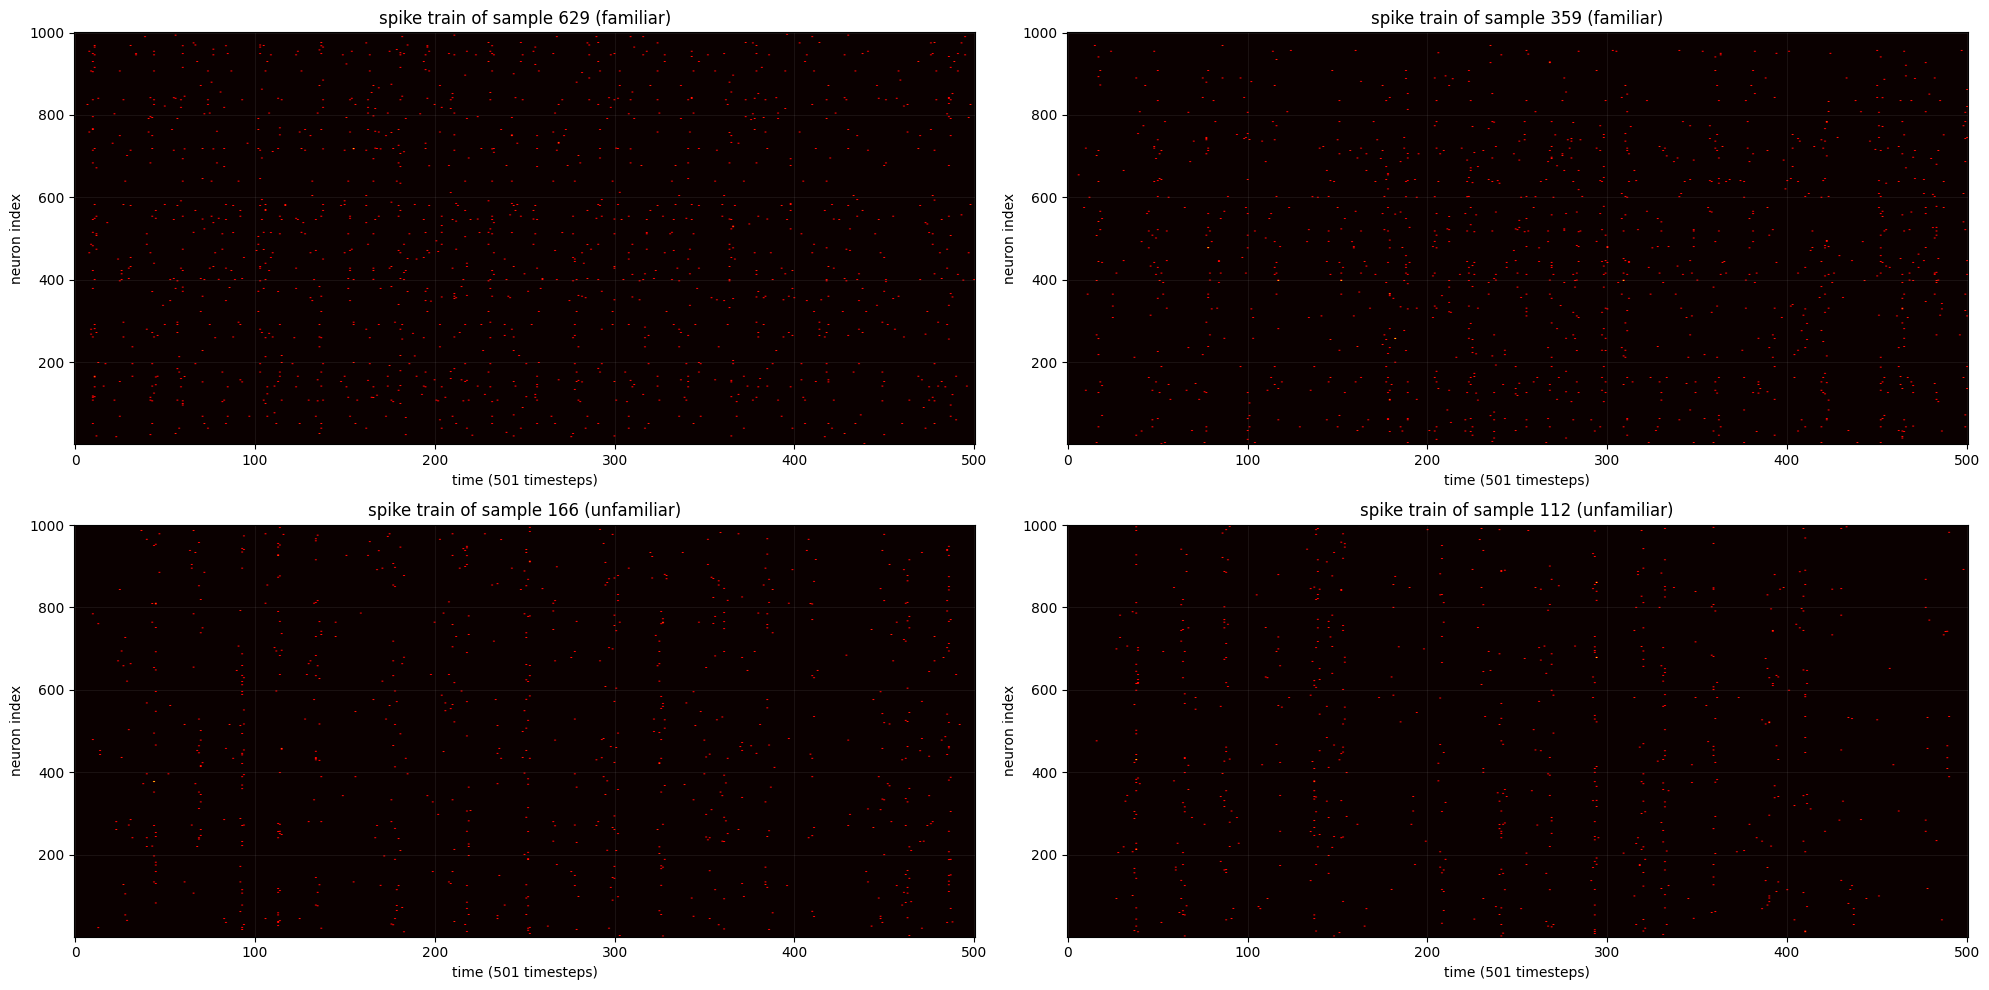

In [4]:
# pick 2 randome samples from rach class (one familiar and one unfamiliar)
sample_nr_familiar = np.random.choice(np.where(y == 1)[0], size=2)
sample_nr_unfamiliar = np.random.choice(np.where(y == 0)[0], size=2)
sample_familiar = X[sample_nr_familiar] 
label_familiar = y[sample_nr_familiar]
sample_unfamiliar = X[sample_nr_unfamiliar]
label_unfamiliar = y[sample_nr_unfamiliar]

print("sample nr familiar:", sample_nr_familiar)
print("sample nr unfamiliar:", sample_nr_unfamiliar)

# plot the spike trains of the two samples
plt.figure(figsize=(20, 10))

cmap=plt.get_cmap('hot')

for i in range(2):
    # plot the spike train of the familiar sample
    plt.subplot(2,2,i+1)
    plt.imshow(sample_familiar[i], origin="lower", aspect='auto', cmap=cmap)
    plt.title(f"spike train of sample {sample_nr_familiar[i]} {'(familiar)' if label_familiar[i] == 1 else '(unfamiliar)'}")
    plt.xlabel("time (501 timesteps)")
    plt.ylabel("neuron index")
    plt.ylim(0.5, 1000.5)
    plt.grid(True, alpha=0.1)
    # plot the spike train of the unfamiliar sample
    plt.subplot(2,2,i+3)
    plt.imshow(sample_unfamiliar[i], origin="lower", aspect='auto', cmap=cmap)
    plt.title(f"spike train of sample {sample_nr_unfamiliar[i]} {'(familiar)' if label_unfamiliar[i] == 1 else '(unfamiliar)'}")
    plt.xlabel("time (501 timesteps)")
    plt.ylabel("neuron index")
    plt.ylim(0.5, 1000.5)
    plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

### Data as mean firing rate per neuron 

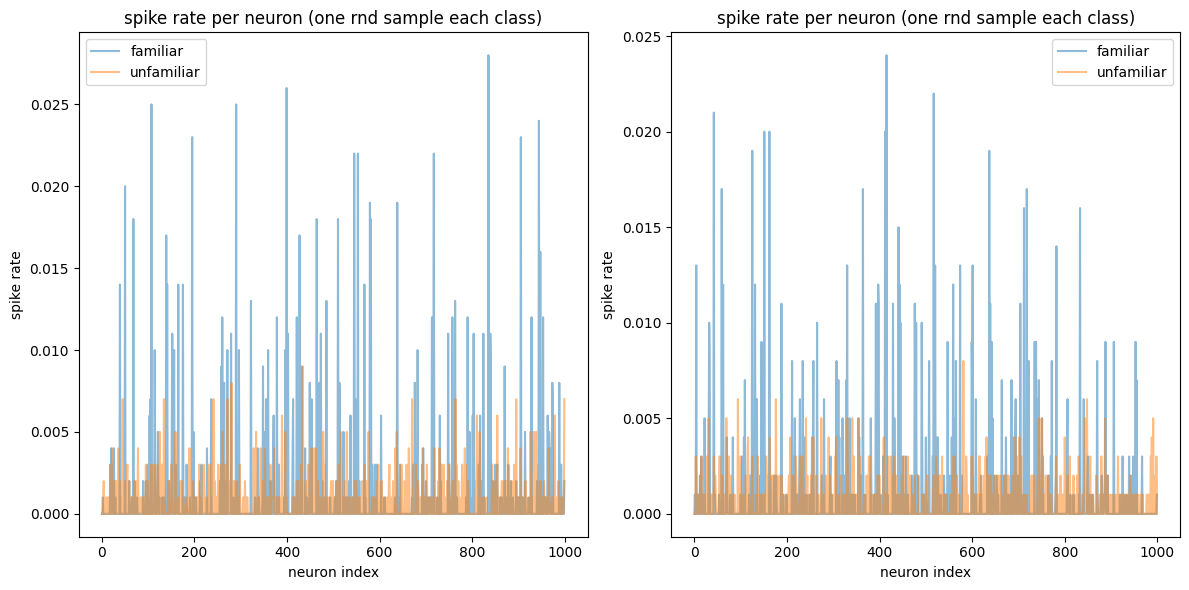

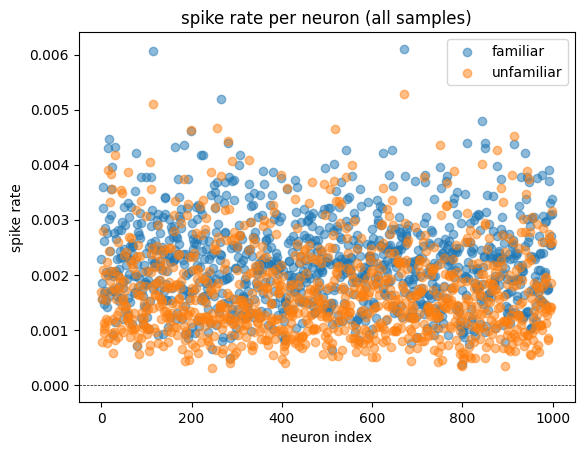

In [5]:
# brief inspection of the spike rates of neurons in each class
plt.figure(figsize=(12,6))
for i in range(2):
    # compute mean firing rate per neuron (sum of each neuron-spikes over timesteps)
    sample_spikeRrate_per_neuron_fm = np.sum(sample_familiar[i], axis=1) / sample_familiar.shape[1]
    sample_spikeRate_per_neuron_unfm = np.sum(sample_unfamiliar[i], axis=1) / sample_unfamiliar.shape[1]
    
    plt.subplot(1,2,i+1)
    plt.plot(sample_spikeRrate_per_neuron_fm, label='familiar', alpha=0.5)
    plt.plot(sample_spikeRate_per_neuron_unfm, label='unfamiliar', alpha=0.5)
    plt.title("spike rate per neuron (one rnd sample each class)")
    plt.xlabel("neuron index")
    plt.ylabel("spike rate")
    plt.legend()

plt.tight_layout()
plt.show()

# do the same but over all samples
# familiar samples
familiar_samples = X[y == 1]
familiar_samples_spikeRate_per_neuron = np.sum(familiar_samples, axis=2) / familiar_samples.shape[2]
# average same neuron over all samples
familiar_samples_spikeRate_per_neuron = np.mean(familiar_samples_spikeRate_per_neuron, axis=0)

# unfamiliar samples
unfamiliar_samples = X[y == 0]
unfamiliar_samples_spikeRate_per_neuron = np.sum(unfamiliar_samples, axis=2) / unfamiliar_samples.shape[2]
unfamiliar_samples_spikeRate_per_neuron = np.mean(unfamiliar_samples_spikeRate_per_neuron, axis=0)

plt.scatter(np.arange(familiar_samples_spikeRate_per_neuron.shape[0]), familiar_samples_spikeRate_per_neuron, label='familiar', alpha=0.5)
plt.scatter(np.arange(unfamiliar_samples_spikeRate_per_neuron.shape[0]), unfamiliar_samples_spikeRate_per_neuron, label='unfamiliar', alpha=0.5)
plt.title("spike rate per neuron (all samples)")
plt.xlabel("neuron index")
plt.ylabel("spike rate")
plt.legend()

# herozontal line at 0.0
plt.axhline(0.0, color='black', linestyle='--', linewidth=0.5)
plt.show()

### <span style="color:blue;">Initial Interpretation</span>
- from the spike trains, it is hard to tell the two classes apart, although in general there seems to be more activity for familiar stimulus.    
- neurons rate coding shows some clearer differentiation as it is easier to grasp at first glance. 

## <span style="color:green;">2 - Neural Data Encoding</span>

Here we transform the sparse binary spiking data into a more condensed representation, better suited for the classification task.  
Our goal is to encode the data in a compact and discriminative way while preserving the underlying structure and neural dynamics of the original data.  

We use the following neural coding methods:
- **Rate coding**: 
    - **firing rate** of each neuron is calculated as the sum of spikes of the neuron over a time window divided by the length of the time window.
    - due to the very high dimensionality of the firing rates feature vector **(N=1000)**, we use **Principal Component Analysis (PCA)** to reduce the dimensionality of the firing rates feature vector.  
      - in the following we use only the first **(N_components=2)** principal components, as they seem to capture most of the variance in the data.
      - #although, futher analysis could be done with higher number of components and different reduction methods#
    - additionally, we calculate the **pobulation mean firing rate** as the mean of the firing rates of all neurons in the population (we consider all available neurons as one population).  
    -> Capture how active specific neurons are in response to the stimulus.
    - very simple, intuitive and efficient to compute. has biological relevance.
    - lacks temporal information comlpletely.
  
- **Synchrony coding** (temporal coding): 
    - **synchrony** between neurons is calculated as the correlation of the spike trains of the neurons over a small time window.  
    - we calculate the **population synchrony** as the mean of the synchrony of all neuron pairs in the population.  
    -> reflects temporal coordination of activity across the population, known/expected to increase in salient or familiar conditions.
    - perserves some temporal information. but computationally more expensive.
    - implemented as a smoothing convolutional (Box / Gaussian) over the spike trains of the neurons, and then the correlation (dot product) with the original spike trains.
- **population sparseness** (population coding): 
    - **population sparseness** charactarizes how distributed or sparse the neural response is.   
    defined as the ratio of the square of the mean firing rate to the mean of the squared firing rates:
    $$
    a = \frac{\left( \frac{1}{N} \sum_{i=1}^{N} r_i \right)^2}{\frac{1}{N} \sum_{i=1}^{N} r_i^2}
    $$
    - where:
        - $a$ is the population sparseness
        - $N$ is the number of neurons
        - $r_i$ is the firing rate of neuron $i$
    - $a \in \left[\frac{1}{N}, 1\right]$:  
    - $a \approx 1$: distributed (all neurons respond equally)  
    - $a \ll 1$: sparse (only few neurons respond) discriminatively   
       
    Reference: Treves-Rolls population sparseness index 


As a final step, we **standardize** all feature vectors (independently) to have zero mean and unit variance.

In [6]:
# neural coding functions

def rate_coding(X):
    """
    Computes the firing rate of neurons from spike trains.
    args:
        X (np.ndarray): Spike trains of shape (samples, neurons, timesteps) or (neurons, timesteps)
    Returns:
        np.ndarray: Firing rates of shape (samples, neurons) or (neurons,)
    """
    timesteps = X.shape[-1]
    firing_rates = np.sum(X, axis=-1) / timesteps
    return firing_rates


def synchrony_index_coding(X, window_size=5, normalize=True, kernel_type="box", gaussian_std=None):
    """
    Computes the synchrony index of neurons from spike trains.
    Args:
        X (np.ndarray): Spike trains of shape (samples, neurons, timesteps)
        window_size (int): Half-width of the smoothing kernel (in timesteps)
        normalize (bool): Whether to normalize by total number of spikes
        kernel_type (str): 'box' or 'gaussian'
        gaussian_std (float or None): Std deviation of Gaussian kernel. If None, defaults to window_size / 2.
    Returns:
        np.ndarray: Synchrony index per sample, shape (samples,)
    """
    samples, neurons, timesteps = X.shape

    # select /initalise kernel
    if kernel_type == "box":
        kernel = np.ones(2 * window_size + 1)
    elif kernel_type == "gaussian":
        std = gaussian_std if gaussian_std is not None else window_size / 2
        kernel = gaussian(2 * window_size + 1, std)
    else:
        raise ValueError("Invalid kernel_type. Use 'box' or 'gaussian'.")

    synchrony_total = np.zeros(samples)

    for s in range(samples):
        spikes = X[s]  # (neurons, timesteps)
        
        # smooth each neuron with selected kernel
        spikes_smooth = np.array([
            convolve(spikes[n], kernel, mode='same') for n in range(neurons)
        ])

        # compute overall synchrony as upper triangle sum of dot products (neuron pairs correlation)
        dot = np.dot(spikes_smooth, spikes.T)
        synchrony_total[s] = np.sum(np.triu(dot, k=1))

    # normalize by total number of spikes in each sample
    if normalize:
        total_spikes = X.sum(axis=(1, 2)) + 1e-8
        synchrony_total /= total_spikes

    return synchrony_total

def population_sparseness_coding(X):
    """
    Computes the Treves-Rolls population sparseness index.
    The Treves-Rolls sparseness index is defined as the ratio of the square of the mean firing rate 
    to the mean of the squared firing rates
    Args:
        X (np.ndarray): Spike trains of shape (samples, neurons, timesteps)
    Returns:
        np.ndarray: Sparseness index per sample, shape (samples,)
    """
    firing_rates = rate_coding(X)  # shape: (samples, neurons)

    # Compute Treves-Rolls sparseness per sample
    mean_rate = np.mean(firing_rates, axis=1)               # (samples,)
    mean_sq_rate = np.mean(firing_rates**2, axis=1)         # (samples,)
    
    sparseness = (mean_rate**2) / (mean_sq_rate + 1e-8)      # Treves-Rolls formula
    
    return sparseness

### Compute and Standardize the Features

In [7]:
# compute features
firing_rates_feature = rate_coding(X)
population_mean_fr_feature = np.mean(firing_rates_feature, axis=1)
synchrony_feature = synchrony_index_coding(X, window_size=5, normalize=True)
population_sparseness_feature = population_sparseness_coding(X)

In [8]:
# standardize/normalize extracted features (mean=0, std=1)
# feature-wise standardization (mean and std per feature)
firing_rates_feature_scaled = StandardScaler().fit_transform(firing_rates_feature)  
population_mean_fr_feature_scaled = StandardScaler().fit_transform(population_mean_fr_feature.reshape(-1, 1))   
synchrony_feature_scaled = StandardScaler().fit_transform(synchrony_feature.reshape(-1, 1))   
population_sparseness_feature_scaled = StandardScaler().fit_transform(population_sparseness_feature.reshape(-1, 1))  

# PCA for the victorized feature (firing rates per neuron)
pca = PCA(n_components=3)
firing_rates_pca = pca.fit_transform(firing_rates_feature_scaled) 
pca_df = pd.DataFrame(firing_rates_pca, columns=["PC1", "PC2", "PC3"])
pca_df['label'] = y

print("firing rates feature shape:", firing_rates_feature_scaled.shape)
print("population mean firing rates feature shape:", population_mean_fr_feature_scaled.shape)
print("synchrony feature shape:", synchrony_feature_scaled.shape)
print("population sparseness feature shape:", population_sparseness_feature_scaled.shape)

# raw (global) scaler features into a dataframe for easier visualization
raw_scaler_features_df = pd.DataFrame({"population_mean_fr": population_mean_fr_feature.flatten(),
                                   "synchrony": synchrony_feature.flatten(),
                                   "population_sparseness": population_sparseness_feature.flatten(),
                                   "fr_PC1": pca_df["PC1"],
                                   "fr_PC2": pca_df["PC2"],
                                   "fr_PC3": pca_df["PC3"]})
raw_scaler_features_df['label'] = y
print("raw and standarised scaler features shape:", raw_scaler_features_df.shape)
display("raw scaler features head:", raw_scaler_features_df.head())

# standarized (global) scaler features into a dataframe for easier visualization
standarised_scaler_features_df = pd.DataFrame({"population_mean_fr": population_mean_fr_feature_scaled.flatten(),
                                   "synchrony": synchrony_feature_scaled.flatten(),
                                   "population_sparseness": population_sparseness_feature_scaled.flatten(),
                                   # standardized PCA components
                                   "fr_PC1": StandardScaler().fit_transform(pca_df["PC1"].values.reshape(-1, 1)).flatten(),
                                   "fr_PC2": StandardScaler().fit_transform(pca_df["PC2"].values.reshape(-1, 1)).flatten(),
                                   "fr_PC3": StandardScaler().fit_transform(pca_df["PC3"].values.reshape(-1, 1)).flatten()})
standarised_scaler_features_df['label'] = y
display("standarized scaler features head:", standarised_scaler_features_df.head())

firing rates feature shape: (800, 1000)
population mean firing rates feature shape: (800, 1)
synchrony feature shape: (800, 1)
population sparseness feature shape: (800, 1)
raw and standarised scaler features shape: (800, 7)


'raw scaler features head:'

,population_mean_fr,synchrony,population_sparseness,fr_PC1,fr_PC2,fr_PC3,label
0,0.000940,16.779193,0.271362,-0.213335,-0.176048,-0.731144,0
1,0.001250,15.148562,0.241823,8.152003,-1.994065,-0.515187,1
2,0.001220,18.394435,0.319211,0.394328,0.092662,-1.091215,0
3,0.001393,17.469914,0.279920,-1.695594,0.047279,-0.773292,1
4,0.001335,17.611360,0.331156,0.402160,0.373255,-1.104577,0


'standarized scaler features head:'

,population_mean_fr,synchrony,population_sparseness,fr_PC1,fr_PC2,fr_PC3,label
0,-2.025162,0.999692,1.678829,-0.045415,-0.041135,-0.173939,0
1,-1.407514,0.235456,1.210750,1.735416,-0.465925,-0.122563,1
2,-1.467287,1.756716,2.437055,0.083945,0.021651,-0.259600,0
3,-1.120607,1.323416,1.814446,-0.360962,0.011047,-0.183966,1
4,-1.236167,1.389708,2.626333,0.085613,0.087213,-0.262778,0


## <span style="color:green;">3 - Exploratory Analysis of Features</span>

Here we analyze and visualize individual features and their distributions as well as the how these features might relate the classes and each others.

- visualize the features as histograms and pairwise scatter plots
- compute the correlation matrix of the features and visualize it as a heatmap.
- project the features into a lower dimensional space (2d) for a wholestic visualization of the data.
- quantify feature distribution between classes using the **Kullback-Leibler divergence** (KL divergence)
  -> this gives initial insight into how much information do the convay in regard to the classification task.

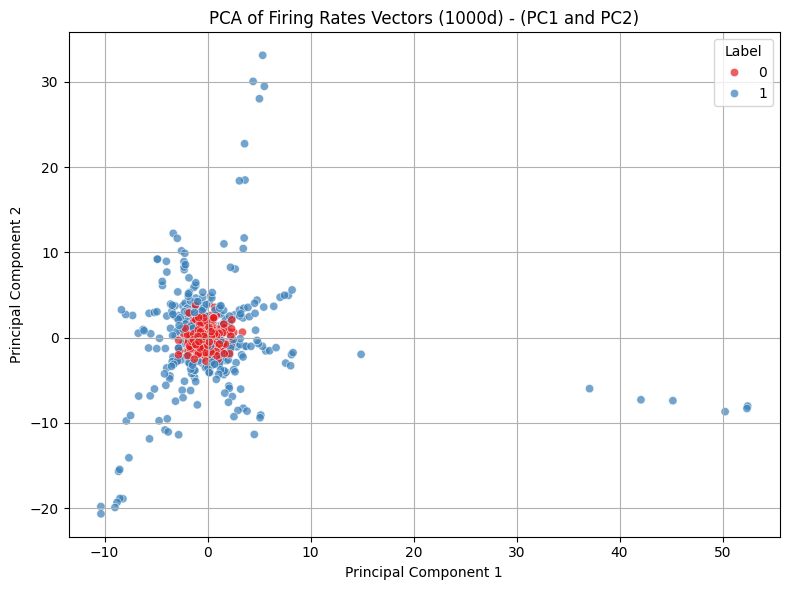

In [9]:
# 2D Scatter plot of PC1 and PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", palette="Set1", alpha=0.7)
plt.title(f"PCA of Firing Rates Vectors ({len(firing_rates_feature_scaled[0])}d) - (PC1 and PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Label")
plt.grid(True)
plt.tight_layout()
plt.show()

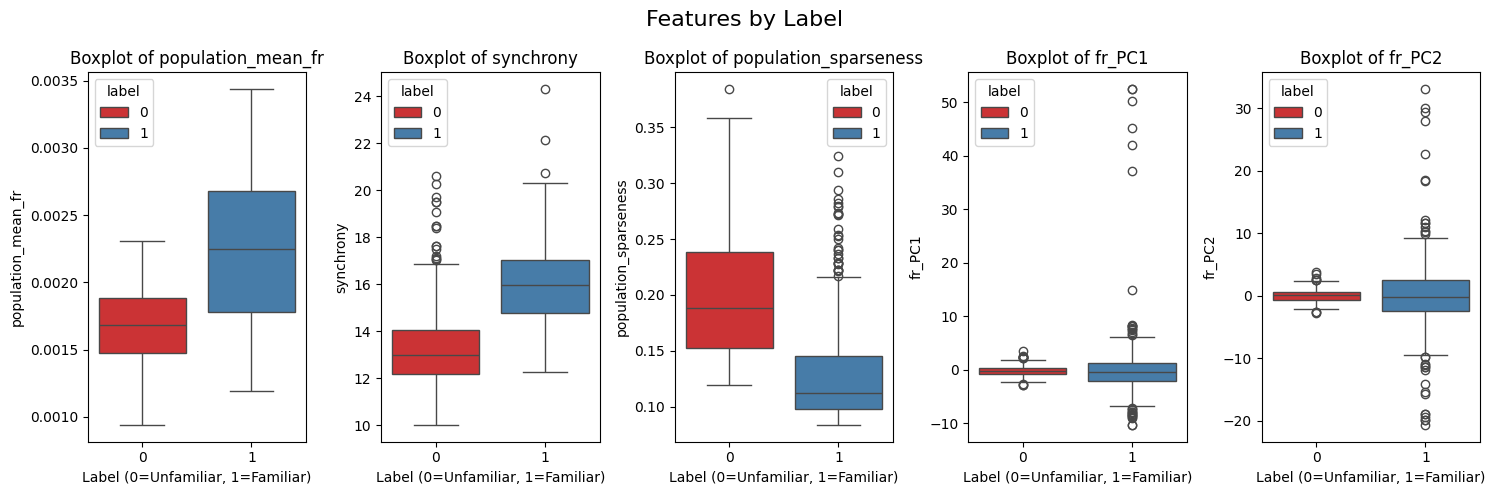

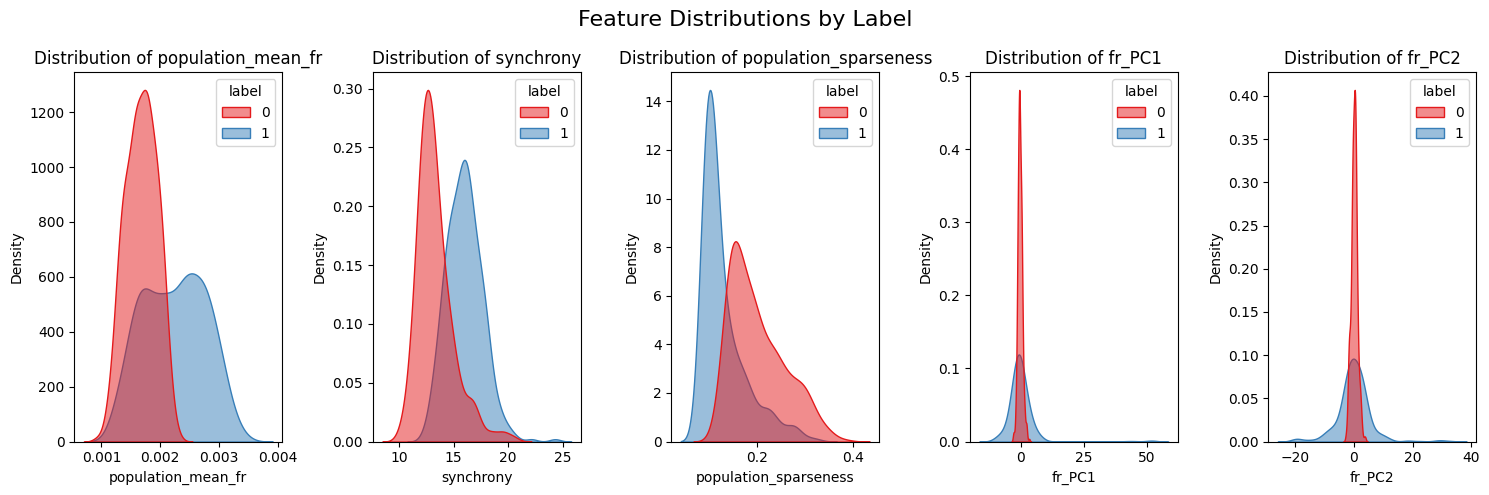

In [10]:
feature_names = ["population_mean_fr", "synchrony", "population_sparseness", "fr_PC1", "fr_PC2"]
# boxplots for each feature
plt.figure(figsize=(15, 5))
plt.suptitle("Features by Label", fontsize=16)
for i, feature in enumerate(feature_names):
    plt.subplot(1, len(feature_names), i + 1)
    sns.boxplot(x="label", y=feature, data=raw_scaler_features_df, palette="Set1", hue="label")
    plt.title(f'Boxplot of {feature}')
    plt.xlabel('Label (0=Unfamiliar, 1=Familiar)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# KDE (Density) plots for each feature
plt.figure(figsize=(15, 5))
plt.suptitle("Feature Distributions by Label", fontsize=16)
for i, feature in enumerate(feature_names):
    plt.subplot(1, len(feature_names), i + 1)
    sns.kdeplot(data=raw_scaler_features_df, x=feature, hue="label", common_norm=False, fill=True, alpha=0.5, palette="Set1")
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


### Pairwise relations and correlation between features

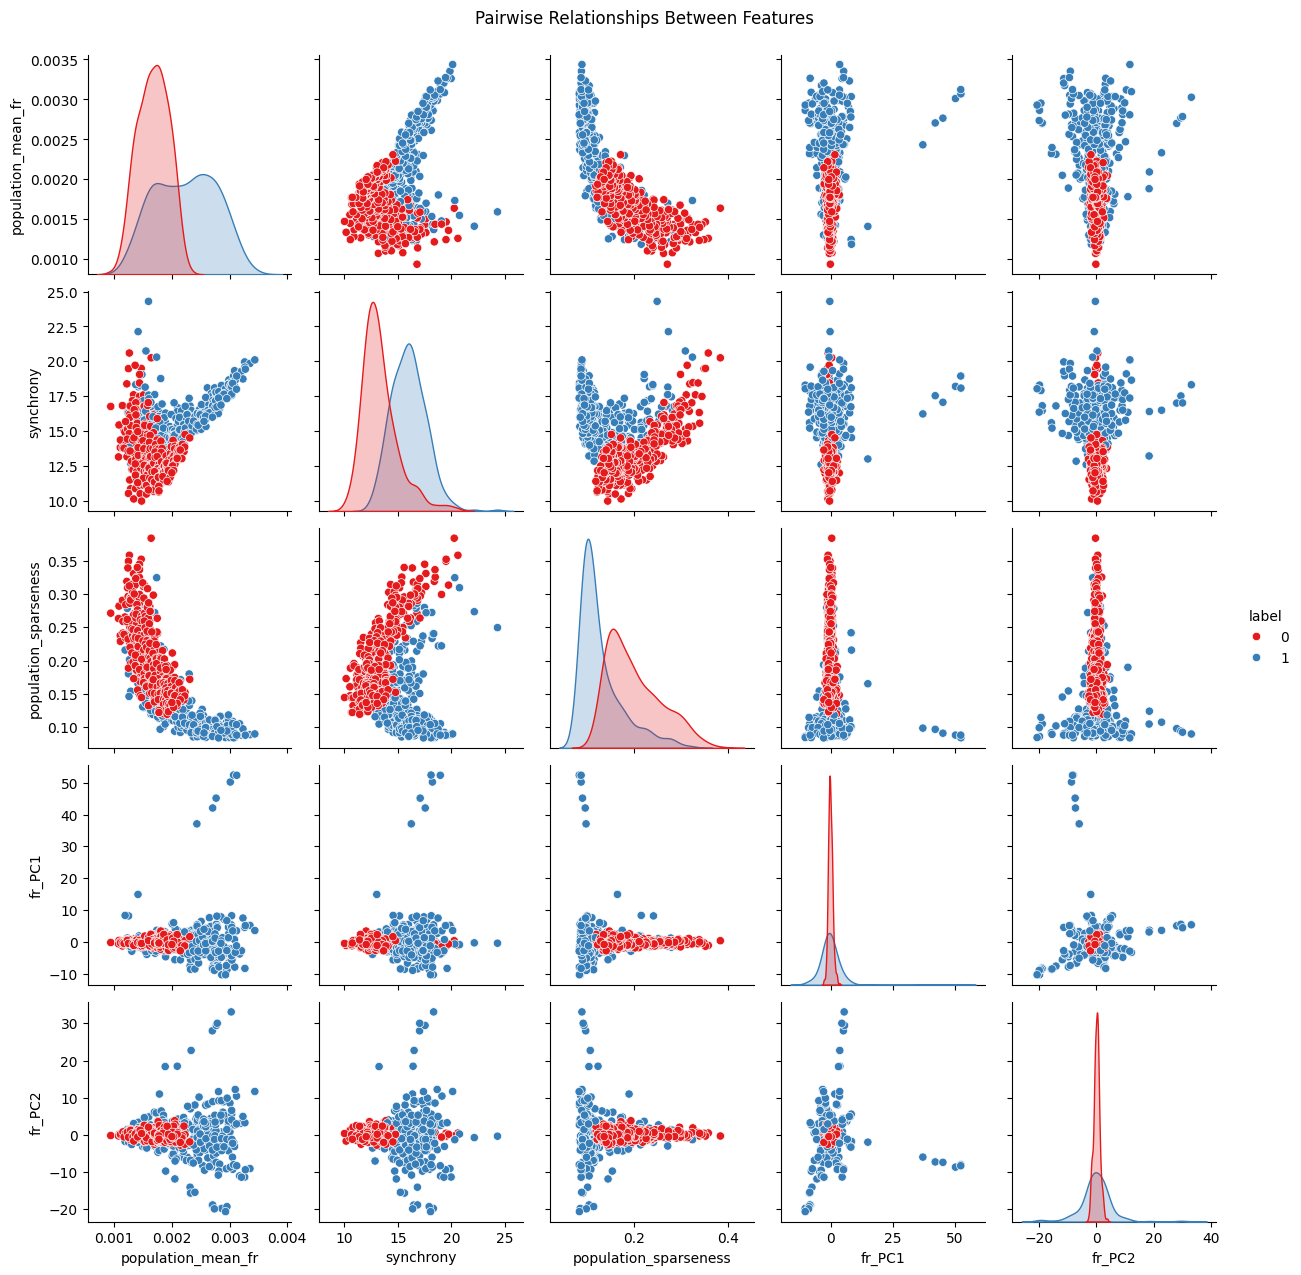

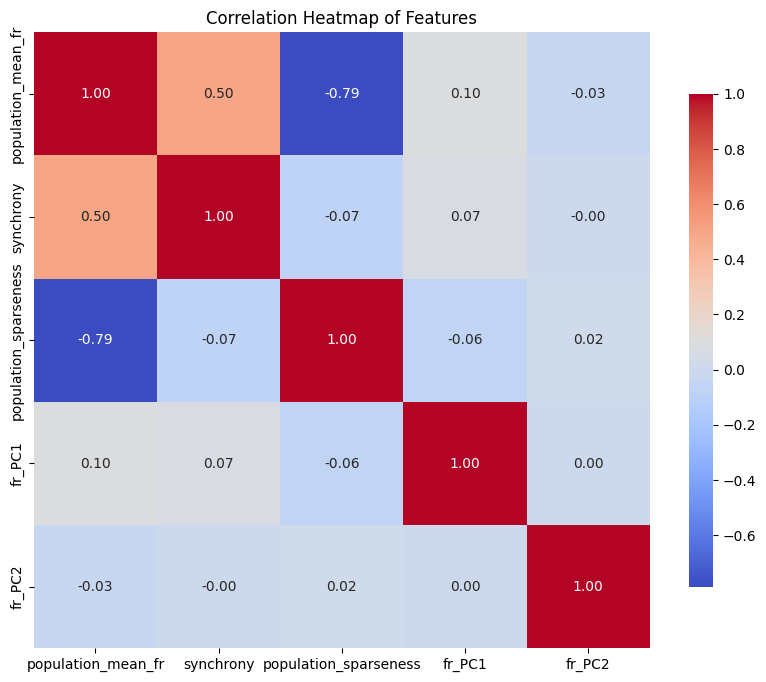

In [11]:
# pairplot to visualize relationships between features
sns.pairplot(raw_scaler_features_df.drop(columns=["fr_PC3"]), hue="label", diag_kind="kde", palette="Set1")
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

# intra-correlation between features as a heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = raw_scaler_features_df.drop(columns=['fr_PC3', 'label']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Features")
plt.show()

### Features projected into Lower Dimensional Space (2D)

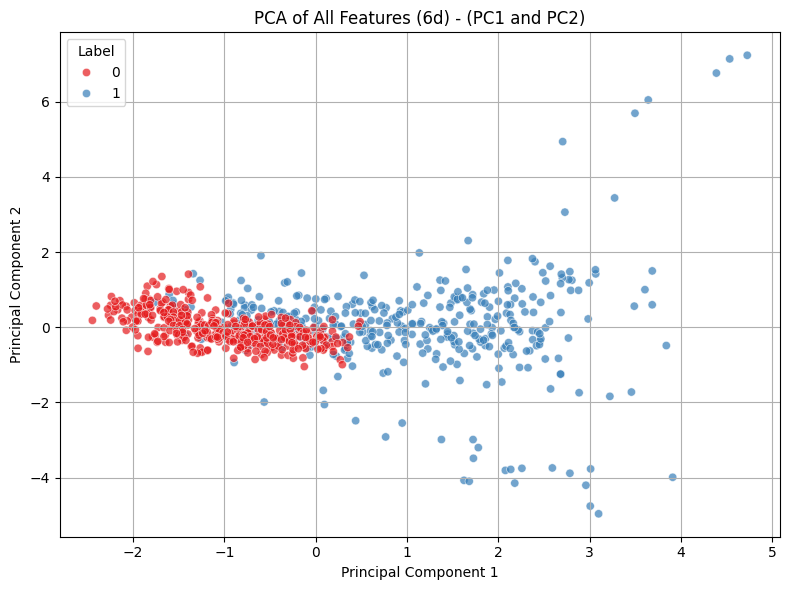

In [12]:
# compute and plot the fist 2 PCs of the PCA of all features
pca_all_features = PCA(n_components=2)
all_features = standarised_scaler_features_df.drop(columns=['label']).values
pca_all_features_result = pca_all_features.fit_transform(all_features)

# create a DataFrame for PCA results
pca_all_features_df = pd.DataFrame(pca_all_features_result, columns=["All_Features_PC1", "All_Features_PC2"])
pca_all_features_df['label'] = y

# 2D Scatter plot of PC1 and PC2 for all features
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_all_features_df, x="All_Features_PC1", y="All_Features_PC2", hue="label", palette="Set1", alpha=0.7)
plt.title(f"PCA of All Features ({len(all_features[0])}d) - (PC1 and PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Label")
plt.grid(True)
plt.tight_layout()
plt.show()

### KL Divergence scores Comparison

KL Divergence per feature (unfamiliar(0 'P') from familiar(1 'Q')):


,Feature,KL_score
1,synchrony,1.857945
4,fr_PC2,0.883518
3,fr_PC1,0.857321
2,population_sparseness,0.851615
0,population_mean_fr,0.750782


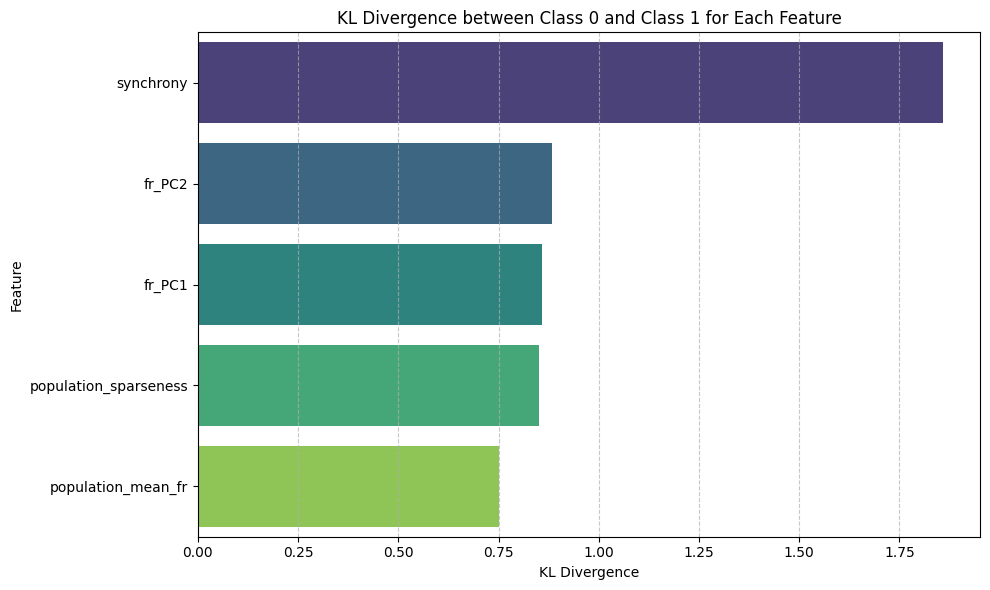

In [13]:
def kl_divergence(P, Q, num_points=1000):
    """Estimate KL divergence between two 1D samples using KDE
    Equation: D_KL(P || Q) = ∫ p(x) log(p(x)/q(x)) dx
    where p(x) and q(x) are the probability density functions of the two distributions.
    args:
        P: 1D array of samples from distribution P
        Q: 1D array of samples from distribution Q
        num_points: number of points to evaluate the KDE on
    returns:
        kl: KL divergence between the two distributions
    """
    
    # estimate the probability density functions using KDE
    kde0 = gaussian_kde(P)
    kde1 = gaussian_kde(Q)

    # a grid of values covering both distributions
    xmin = min(P.min(), Q.min())
    xmax = max(P.max(), Q.max())
    x_grid = np.linspace(xmin, xmax, num_points)

    p = kde0(x_grid)
    q = kde1(x_grid)

    # normalize 
    p /= np.sum(p)
    q /= np.sum(q)

    # small epsilon to avoid division by zero
    eps = 1e-10
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    kl = entropy(p, q) # KL divergence here as relative entropy (ends up as the same standard KLD equation)
    return kl

# KL divergence for each feature (unfamiliar(0 'P') from familiar(1 'Q'))
kl_scores = {}
for feature in feature_names:
    x0 = standarised_scaler_features_df[standarised_scaler_features_df["label"] == 0][feature]
    x1 = standarised_scaler_features_df[standarised_scaler_features_df["label"] == 1][feature]
    kl = kl_divergence(x0, x1)
    kl_scores[feature] = kl

# sorted KL divergence scores
kl_sorted_df = pd.DataFrame(list(kl_scores.items()), columns=["Feature", "KL_score"]).sort_values(by="KL_score", ascending=False)
# display KL divergence scores
print("KL Divergence per feature (unfamiliar(0 'P') from familiar(1 'Q')):")
display(kl_sorted_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=kl_sorted_df, x="KL_score", y="Feature", palette="viridis", hue="Feature")
plt.xlabel('KL Divergence')
plt.title('KL Divergence between Class 0 and Class 1 for Each Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### <span style="color:blue;">Interpretation / justification</span>
- Feature Distributions and Class Separation:
  - all features show a fine degree of separation between the two classes as all have visiually distinct distributions over classes.  
    - **Synchrony** and **population sparseness** show the most distinct distributions.

- Correlation Analysis:
  - the correlation matrix shows that the features are not highly correlated with each other, which is a good sign for the our feature selection (used neural coding methods).  
  - only **Population Sparseness** and **Population Mean Firing Rate** negativly correlated (strongly r=-0.79). this is reasonable as higher fighing rates corrosponds usually to more structured and less sparse activity.
  
- 2d Projection of the features:
  - the PCA projection of the features shows that the two classes are well separated in the selected feature space.

- KL Divergence scores:   
We chose the KL Divergence because it directly quantifies how much the distribution of a feature on unfamiliar stimuli differs from familiar stimuli. It allows us as well to not assume any specific distribution for the features and it has a relative entropy term that allows us to rank the features based on their information content in regard to the class labels.   
    ->
  - the KL divergence scores show that all features have a significant amount of information about the class labels **(all > 0.75)**.
  - **Synchrony** has the highest KL divergence score **(1.85)** significantly higher value than the other features **(ranege [0.75 - 0.91])**. this supports the visual observation mentioned above.

overall, we could conclude some general features of the neural responses to familiar and unfamiliar stimuli:
- **Synchrony**:
  - higher synchrony for familiar stimuli, meaning more neurons are firing together when the stimulus is familiar. 
- **Population Sparseness**: 
  - less sparse activity for familiar stimuli, meaning more neurons are active and firing structurlly together when the stimulus is familiar.
- **Firing Rate**: 
  - generally higher mean firing rates for familiar stimuli (not very distinct).
- **PC1 and PC2**:
  - familiar stimuli have higher values absolute values for the first two principal components, further interpretion is unclear.
  

## <span style="color:green;">4 - Model Intiialization and Training </span>

We train a set of diverse classifiers on two feature sets:

  - All extracted features

  - Top 3 features ranked by either Random Forest importance or KL divergence

### <span style="color:blue;">Interpretation / justification</span>

* The selected models serve mainly for both insight/diagnostic purposes and performance benchmarking:   
(all of these models have the potentional to perform well on the task, but we want to see how well they perform in comparison to each others given their different assumptions and complexity)
    
  - **Logistic Regression** (linear baseline):  
    - A simple, interpretable model to assess linear separability and serve as a performance baseline.

  - **Polynomial Logistic Regression**:  
    - Captures non-linear feature interactions through polynomial basis expansion; useful for detecting higher-order patterns.

  - **Spline Logistic Regression**:
    - Uses smooth, flexible basis functions to model non-linear but structured relationships in the neural features.

  - **Random Forest**:
    - A robust, non-linear ensemble model that handles feature interactions well. Used both for classification and to derive feature importance.

  - **Support Vector Machine** (RBF Kernel):
    - A strong non-linear classifier, well-suited for high-dimensional data. Included for performance comparison with simpler models. ( we expected to perform well )

  - **K-Nearest Neighbors** (KNN):
    - A non-parametric model relying purely on distance in feature space, used to test if simple local similarity is sufficient for classification.

* The randome forest feature heirarchy (implementation cell below): 
    
  Random Forest ranks **population sparseness** as the top feature, while KL divergence places it 4th. Both methods agree on the high importance of **synchrony** (KL: 1st, RF: 2nd).   
Random Forest ranks **fr_PC1** and **fr_PC2** lowest, likely because tree-based models favor features that lead to simple, early splits, whereas PCA components, though informative, are usually less directly aligned with class boundaries
KL divergence, in contrast, measures pure distributional separation so we know the PCs of the firing rates are informative but based on random forest their contribution might be compensated by the other features (possibly **mean population firing rate**).  
   
  Overall, both methods highlight **synchrony** and **population sparseness** as key features, with lower-rank differences likely reflecting the evaluation biases of each method or correlation in these features' information content.   

### Initialization of the Models

In [14]:
RANDOME_STATE = 25

# hyperparameters for the models
# Logistic Regression
LR_MAX_ITER = 4000
REGULIZATION_TERM = "l2"
# Polynomial LR
DEGREE_POLY = 3
# Spline LR
DEGREE_SPLINE = 3
N_KNOTS_SPLINE = 5
# SVM
SVM_KERNEL = 'rbf'
# Random Forest
RF_N_ESTIMATORS = 100
# KNN
KNN_N_NEIGHBORS = 10

models = {
    "Logistic_Regression": 
        LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM),
    "Logistic_Regression_Polynomial":
        make_pipeline(PolynomialFeatures(degree=DEGREE_POLY, include_bias=False), 
                      LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM)),
    "Logistic_Regression_Spline":
        make_pipeline(SplineTransformer(degree=DEGREE_SPLINE, n_knots=N_KNOTS_SPLINE, include_bias=False), 
                      LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM)),
    f"SVM_{SVM_KERNEL}": 
        SVC(kernel=SVM_KERNEL, probability=True),
    "Random_Forest": 
        RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, min_samples_split=2, random_state=RANDOME_STATE),
    "KNN": 
        KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, weights='uniform')
}

### Setup of the training and testing data

In [21]:
###### IF YOU WANT TO USE FIRING RATES PER NEURON VECTORS (IT WORKS FINE BUT IT IS EXECULDED FOR NOW)
# selected_features = [
#     "population_mean_fr",
#     "synchrony",
#     "population_sparseness",
#     # "fr_PC1",
#     # "fr_PC2",
#     "fr_vectors" 
# ]

# fr_vectors_reduction = 5

# if "fr_vectors" in selected_features:
#     # get all other features from the df, and concatenate them after that with the firing rates vectors
#     selected_features_ = list(filter(lambda x: x != "fr_vectors", selected_features))
#     X_features = standarised_scaler_features_df[selected_features_].values
#     # concatenate firing rates vectors

#     pca = PCA(n_components=fr_vectors_reduction)
#     firing_rates_reduced = pca.fit_transform(firing_rates_feature_scaled)
#     X_features = np.concatenate((X_features, firing_rates_reduced), axis=1)

# else:
#     X_features = standarised_scaler_features_df[selected_features].values
######

# select data features to use for training the models
selected_features = [
    "population_mean_fr",
    "synchrony",
    "population_sparseness",
    "fr_PC1",
    "fr_PC2",
]

# get all scaled features as an array (samples, n_features) from the df
X_features = standarised_scaler_features_df[selected_features].values
labels = standarised_scaler_features_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_features, labels, test_size=0.2, random_state=RANDOME_STATE, shuffle=True
)

print("X_features shape:", X_features.shape, "labels shape:", labels.shape)
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

X_features shape: (800, 5) labels shape: (800,)
X_train shape: (640, 5) y_train shape: (640,)
X_test shape: (160, 5) y_test shape: (160,)


### Fit all models on the training data

In [22]:
# loop over the models and fit them to the training data
print('selected_features for training:', *selected_features, "-"*40, sep="\n-")
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    print("Done")

selected_features for training:
-population_mean_fr
-synchrony
-population_sparseness
-fr_PC1
-fr_PC2
-----------------------------------------
Training Logistic_Regression... Done
Training Logistic_Regression_Polynomial... Done
Training Logistic_Regression_Spline... Done
Training SVM_rbf... Done
Training Random_Forest... Done
Training KNN... Done


### Get Ranked Features from Random Forest

,Feature,Importance
2,population_sparseness,0.354451
1,synchrony,0.297618
0,population_mean_fr,0.174150
4,fr_PC2,0.108894
3,fr_PC1,0.064887


Random Forest accuracy: 0.9750


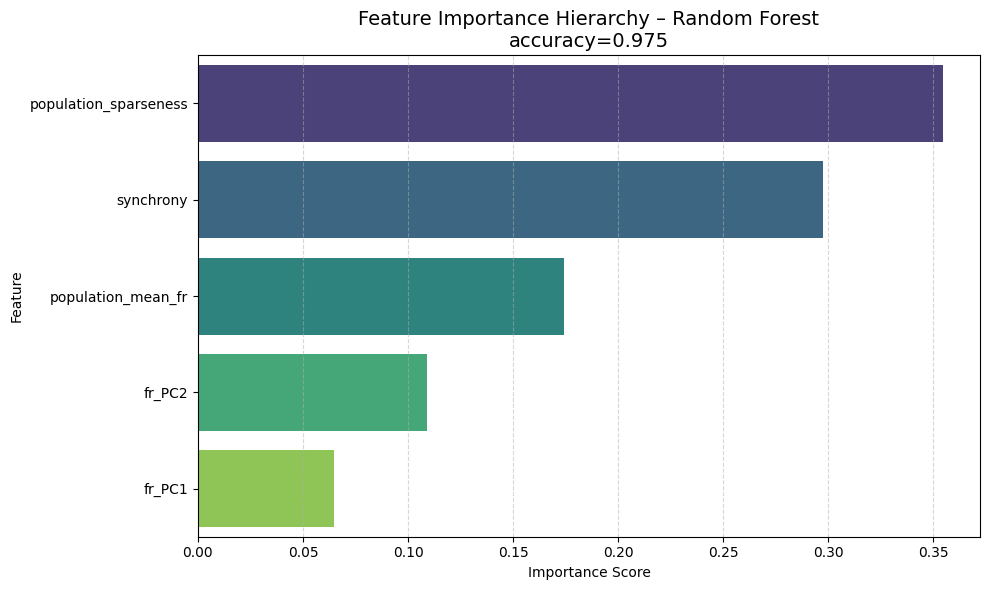

In [24]:
# get the feature heirarchy suggested by the Random Forest model
rf_model = models["Random_Forest"]

# feature names
core_features = [f for f in selected_features if f != "fr_vectors"]
all_feature_names = core_features

# extract feature importances and sort them
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
display(feature_importance_df)

# calculate the accuracy of the Random Forest model as a reference for the reliability of the feature importance
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Random Forest accuracy: {rf_accuracy:.4f}")

# plot results
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="viridis", hue="Feature")
plt.title(f"Feature Importance Hierarchy – Random Forest\naccuracy={rf_accuracy}", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Train on top features suggested by the random forest model

repeat the same steps as above but for different feature sets (top 3 features based on the random forest importance scores)

In [ ]:
# new instances of the same models
models_rf = {
    "Logistic_Regression": 
        LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM),
    "Logistic_Regression_Polynomial":
        make_pipeline(PolynomialFeatures(degree=DEGREE_POLY, include_bias=False), 
                      LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM)),
    "Logistic_Regression_Spline":
        make_pipeline(SplineTransformer(degree=DEGREE_SPLINE, n_knots=N_KNOTS_SPLINE, include_bias=False), 
                      LogisticRegression(max_iter=LR_MAX_ITER, penalty=REGULIZATION_TERM)),
    f"SVM_{SVM_KERNEL}": 
        SVC(kernel=SVM_KERNEL, probability=True),
    "Random_Forest": 
        RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, min_samples_split=2, random_state=RANDOME_STATE),
    "KNN": 
        KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, weights='uniform')
}

# get the top n features from the feature importance
top_n_rf_features = 3
selected_features_rf = feature_importance_df.head(top_n_rf_features)["Feature"].values.tolist()

X_features_rf = standarised_scaler_features_df[selected_features_rf].values
labels = standarised_scaler_features_df["label"].values

print("X_features shape:", X_features_rf.shape, "labels shape:", labels.shape, "\n")

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_features_rf, labels, test_size=0.2, random_state=RANDOME_STATE, shuffle=True
)

print(f"selected top {top_n_rf_features} features for training:", *selected_features_rf, "-"*40, sep="\n-")  

for name, model in models_rf.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_rf, y_train_rf)
    print("Done")

X_features shape: (800, 3) labels shape: (800,) 

selected top 3 features for training:
-population_sparseness
-synchrony
-population_mean_fr
-----------------------------------------
Training Logistic_Regression... Done
Training Logistic_Regression_Polynomial... Done
Training Logistic_Regression_Spline... Done
Training SVM_rbf... Done
Training Random_Forest... Done
Training KNN... Done


## <span style="color:green;">5 - Model Evaluation </span>

Here we evaluate the performance of the trained models on the test data (for both feature sets, all features and top 3 features by randome forest).  

- we evaluate once on one set of train / test data split as well as on **k-fold cross-validation** (k=5) to get a better estimate of the models performance.
- we use Acuracy as the main performance metric
- we plot the classification landscape and the decision boundaries of the models on the test data.

<span style="color:blue;">justification</span> of the performance metric (accuracy):   
   

We use **accuracy** as the main performance metric because the dataset is balanced (similar/equal number of classes, 400 each), and we are interested in overall classification correctness. Accuracy is appropriate when both classes are equally important and misclassification costs are symmetric.

Metrics like **F1-score** or **precision/recall** would be better suited in cases of class imbalance or when false positives and false negatives have different costs, such as in medical or anomaly detection tasks.

### Evaluation of the models on the test data

In [34]:
# evaluate the models once on the test set
def evaluate_models(models, X_test, y_test):
    """
    Evaluate models on the test set and return the accuracy results along side the models predictions.
    Args:
        models (dict): Dictionary of model names and their instances
        X_test (np.ndarray): Test features
        y_test (np.ndarray): Test labels
    Returns:
        results (list): List of dictionaries with model name, accuracy, and F1 score
        classification_reports (list): List of classification reports for each model
        models_predictions (dict): Dictionary of model names and their predictions
    """
    VERBOSE = False
    results = []
    classification_reports = []
    models_predictions = {}

    for name, model in models.items():
        print(f"Evaluating {name}...", end=" ")
        # make predictions
        y_pred = model.predict(X_test)

        # calculate accuracy and f1 score
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred) 

        # get classification report
        report = classification_report(y_test, y_pred, target_names=["Unfamiliar", "Familiar"], output_dict=True)

        print(f"Done")

        # save results  
        results.append({
            "Model": name,
            "Accuracy": round(acc, 3),
            "F1_Score": round(f1, 3)
        })

        report["Model"] = name
        classification_reports.append(report) # save reports for later use
        models_predictions[name] = y_pred

        if VERBOSE:
            print(f"\n{name}")
            print("-" * len(name))
            print(f"Accuracy:  {acc:.3f}")
            print(f"F1_Score:  {f1:.3f}")
            print(f"Classification Report:\n{classification_report(y_test, y_pred, target_names=['Unfamiliar', 'Familiar'])}")
            print("-" * 40)

    return results, classification_reports, models_predictions


def kFold_cross_val_evaluate_models(models, X, y, k_folds=5, scoring_metric="accuracy"):
    """
    Evaluate models using k-fold cross-validation and return the results.
    Args:
        models (dict): Dictionary of model names and their instances
        X (np.ndarray): Features
        y (np.ndarray): Labels
        k_folds (int): Number of folds for cross-validation
        scoring_metric (str): Scoring metric for evaluation ('accuracy', 'f1', 'log_loss')
    Returns:
        cross_val_results_df (pd.DataFrame): DataFrame with cross-validation results
    """
    cross_val_results = []
    for name, model in models.items():
        # perform k-fold cross-validation on (a cloned) model
        cv_scores = cross_val_score(clone(model), X, y, cv=k_folds, scoring=scoring_metric)

        # save mean and std of results
        cross_val_results.append({
            "Model": name,
            f"CV_{scoring_metric}_mean": round(np.mean(cv_scores), 3),
            f"CV_{scoring_metric}_Std": round(cv_scores.std(), 3)
        })

    cross_val_results_df = pd.DataFrame(cross_val_results).sort_values(f"CV_{scoring_metric}_mean", ascending=False)
    cross_val_results_df.set_index("Model", inplace=True)
    return cross_val_results_df

In [ ]:
# k-fold cross-validation
SCORING_METRIC = "accuracy"
K_FOLDS = 5

# k-fold cross-validation for all features
cross_val_results_df = kFold_cross_val_evaluate_models(models, X_features, labels, k_folds=K_FOLDS, scoring_metric=SCORING_METRIC)
print(f"Cross-Validation Results (all features n={len(selected_features)}):")
display(cross_val_results_df)

# k-fold cross-validation for top n from RF
cross_val_results_df_rf = kFold_cross_val_evaluate_models(models_rf, X_features_rf, labels, k_folds=K_FOLDS, scoring_metric=SCORING_METRIC)
print(f"Cross-Validation Results (Top Features from rf n={top_n_rf_features}):")
display(cross_val_results_df_rf)

Cross-Validation Results (all features n=5):


,CV_accuracy_mean,CV_accuracy_Std
Model,,
SVM_rbf,0.938,0.079
Logistic_Regression,0.926,0.084
Logistic_Regression_Polynomial,0.924,0.072
KNN,0.881,0.123
Logistic_Regression_Spline,0.870,0.126
Random_Forest,0.842,0.132


Cross-Validation Results (Top Features from rf n=3):


,CV_accuracy_mean,CV_accuracy_Std
Model,,
Logistic_Regression,0.929,0.087
SVM_rbf,0.925,0.092
Logistic_Regression_Polynomial,0.919,0.072
KNN,0.886,0.113
Logistic_Regression_Spline,0.872,0.126
Random_Forest,0.834,0.142


In [28]:
# evaluate models trained on all features
results, classification_reports, models_predictions = evaluate_models(models, X_test, y_test)

# final summary DataFrame
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
# set Model as index
results_df.set_index("Model", inplace=True)

print(f"\nModel Comparison Summary (all features n={len(selected_features)}):")
display(results_df)

# evaluate models trained on top n features from RF
results_rf, classification_reports_rf, models_predictions_rf = evaluate_models(models_rf, X_test_rf, y_test_rf)
# final summary DataFrame
results_rf_df = pd.DataFrame(results_rf).sort_values("Accuracy", ascending=False)
# set Model as index
results_rf_df.set_index("Model", inplace=True)
print(f"\nModel Comparison Summary (Top Features from rf n={top_n_rf_features}):")
display(results_rf_df)


Evaluating Logistic_Regression... Done
Evaluating Logistic_Regression_Polynomial... Done
Evaluating Logistic_Regression_Spline... Done
Evaluating SVM_rbf... Done
Evaluating Random_Forest... Done
Evaluating KNN... Done

Model Comparison Summary (all features n=5):


,Accuracy,F1_Score
Model,,
Logistic_Regression_Polynomial,0.988,0.986
SVM_rbf,0.988,0.986
Random_Forest,0.975,0.973
KNN,0.975,0.972
Logistic_Regression,0.969,0.966
Logistic_Regression_Spline,0.950,0.943


Evaluating Logistic_Regression... Done
Evaluating Logistic_Regression_Polynomial... Done
Evaluating Logistic_Regression_Spline... Done
Evaluating SVM_rbf... Done
Evaluating Random_Forest... Done
Evaluating KNN... Done

Model Comparison Summary (Top Features from rf n=3):


,Accuracy,F1_Score
Model,,
Logistic_Regression_Polynomial,0.981,0.979
SVM_rbf,0.981,0.979
Logistic_Regression,0.963,0.958
Random_Forest,0.963,0.959
KNN,0.963,0.958
Logistic_Regression_Spline,0.950,0.943


### Plot the classification landscape and decision boundaries

In [36]:
# convert the models predictions dicts to DataFrames for easier visualization
models_predictions_df = pd.DataFrame(models_predictions)
# add true labels to the DataFrame
models_predictions_df['true_label'] = y_test
display("models predictions head:", models_predictions_df.head())

# same for the RF models
models_predictions_df_rf = pd.DataFrame(models_predictions_rf)
models_predictions_df_rf['true_label'] = y_test
display("models predictions RF head:", models_predictions_df_rf.head())

'models predictions head:'

,Logistic_Regression,Logistic_Regression_Polynomial,Logistic_Regression_Spline,SVM_rbf,Random_Forest,KNN,true_label
0,1,1,1,1,1,1,1
1,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1
4,0,0,0,0,0,0,0


'models predictions RF head:'

,Logistic_Regression,Logistic_Regression_Polynomial,Logistic_Regression_Spline,SVM_rbf,Random_Forest,KNN,true_label
0,1,1,1,1,1,1,1
1,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1
4,0,0,0,0,0,0,0


In [38]:
# plotting functions for classification landscapes and decision boundaries
def plot_classification_landscape(X, true_labels, predicted_labels, feature_names=None, title="", ax=None):
    """
    Plots the classification landscape of a classifier in 2d.
    Args:
        X (np.ndarray): Feature matrix (n_samples, n_features)
        true_labels (np.ndarray): True labels (n_samples,)
        predicted_labels (np.ndarray): Predicted labels (n_samples,)
        feature_names (list): List of feature names
        title (str): Title of the plot
        ax (matplotlib.axes.Axes): Optional matplotlib Axes to plot into
    Returns:
        ax (matplotlib.axes.Axes): The axes object used for plotting
    """

    class_names = {0: "Unfamiliar", 1: "Familiar"}
    palette = sns.color_palette("Set1", n_colors=len(class_names))

    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True

    if len(X.shape) == 1:
        X = X.reshape(-1, 1)

    # 1D case: plot as strip or jittered scatter
    if X.shape[1] == 1:
        df = pd.DataFrame({
            "Feature": X[:, 0],
            "TrueLabel": true_labels,
            "PredLabel": predicted_labels
        })
        df["Correct"] = df["TrueLabel"] == df["PredLabel"]
        df["ClassLabel"] = df["TrueLabel"].map(class_names)

        sns.stripplot(data=df, x="ClassLabel", y="Feature", hue="Correct",
                      dodge=True, palette={True: "green", False: "red"},
                      jitter=True, alpha=0.7, marker="o",
                      ax=ax)
        ax.set_title(title)
        ax.set_ylabel(feature_names[0] if feature_names else "Feature")
        ax.grid(True, linestyle="--", alpha=0.4)

    # 2D case: plot features directly
    elif X.shape[1] == 2:
        df = pd.DataFrame(X, columns=feature_names if feature_names else ["Feature 1", "Feature 2"])
        df["TrueLabel"] = true_labels
        df["PredLabel"] = predicted_labels
        df["Correct"] = df["TrueLabel"] == df["PredLabel"]
        df["ClassLabel"] = df["TrueLabel"].map(class_names)

        sns.scatterplot(
            data=df,
            x=df.columns[0], y=df.columns[1],
            hue="ClassLabel",
            style="Correct",
            palette=palette,
            markers={True: "o", False: "X"},
            s=70,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.75,
            ax=ax
        )

        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.5)
        
        # legend
        class_handles = [
            mpatches.Patch(color=palette[i], label=cls)
            for i, cls in enumerate(class_names.values())
        ]
        correct_handles = [
            mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=7, label='Correct'),
            mlines.Line2D([], [], color='black', marker='X', linestyle='None', markersize=7, label='Incorrect')
        ]
        ax.legend(handles=class_handles + correct_handles, title="Class/Correctness", loc="upper right")


    # >2D case -> PCA to project to 2D
    else:
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X) # project to 2D (PC1, PC2)
        # plot as if it was 2D with features (PC1, PC2)
        plot_classification_landscape(X_2d, true_labels, predicted_labels, feature_names=["PC1", "PC2"], title=title, ax=ax)

    if show_plot:
        plt.tight_layout()
        plt.draw()

    return ax

def plot_2d_decision_boundary(X, model, levels=1, resolution=100, alpha=0.3, cmap="coolwarm", title=None,ax=None):
    """
    Plots the decision boundary of a classifier in 2D.
    Args:
        X (np.ndarray): Feature matrix (n_samples, n_features)
        model (sklearn.base.BaseEstimator): Trained classifier
        levels (int or list): Number of levels for contour plot
        resolution (int): Resolution of the grid for decision boundary
        alpha (float): Transparency of the contour fill
        cmap (str): Colormap for the contour fill
        title (str): Title of the plot
        ax (matplotlib.axes.Axes): Optional matplotlib Axes to plot into
    Returns:
        ax (matplotlib.axes.Axes): The axes object used for plotting
    """

    if X.shape[1] <= 1:
        # raise ValueError("X must have at least 2 features for 2D plotting")
        print("X must have at least 2 features")
        return None
    
    X_2d = X.copy()

    used_PCA = False
    if X.shape[1] > 2:
        # create a PCA projection
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X)
        used_PCA = True
    

    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True

    # grid as a descrete space for the decision boundary
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # if PCA was used, we need to transform the grid back to original space before making predictions
    if used_PCA: 
        grid = pca.inverse_transform(grid)

    # Get prediction scores
    try:
        if hasattr(model, "predict_proba"):
            Z = model.predict_proba(grid)[:, 1]  # probability for class 1
        else:
            Z = model.predict(grid)
    except Exception:
        # raise ValueError("Model must have predict_proba or predict method")
        print("Model must have predict_proba or predict method")
        return None

    Z = Z.reshape(xx.shape)

    # plot contour
    ax.contour(xx, yy, Z, levels=levels, alpha=alpha, linewidths=2, colors="black") # decision boundary
    ax.contourf(xx, yy, Z, levels=levels, alpha=alpha, cmap=cmap) # split surface / fill
    if title is not None:
        ax.set_title(title)

    if show_plot:
        plt.tight_layout()
        plt.draw()
        
    return ax

# helper function for plotting combining the plots for a set of models into one figure
def plot_model_set_landscapes(X, models_predictions_df, model_dict, results_df, selected_features, title_prefix=""):
    """
    Plots the classification landscapes and decision boundaries for a set of models.
    Args:
        X (np.ndarray): Feature matrix (n_samples, n_features)
        models_predictions_df (pd.DataFrame): DataFrame with true labels and model predictions
        model_dict (dict): Dictionary of model names and their instances
        results_df (pd.DataFrame): DataFrame with model results
        selected_features (list): List of feature names
        title_prefix (str): Prefix for the plot title
    Returns:
        None
    """
    n_models = len(model_dict)
    n_cols = 3
    # calculate number of rows needed for the subplots
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for idx, model_name in enumerate(model_dict):
        ax = axes[idx]
        plot_classification_landscape(
            X,
            true_labels=models_predictions_df["true_label"],
            predicted_labels=models_predictions_df[model_name],
            feature_names=selected_features,
            title=f"{model_name}\nAcc: {results_df.loc[model_name]['Accuracy']:.2f}",
            ax=ax
        )
        plot_2d_decision_boundary(X, model=model_dict[model_name], ax=ax)

    # turn off unused axes
    for ax in axes[n_models:]:
        ax.axis("off")

    fig.suptitle(f"Classification Landscapes – {title_prefix}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

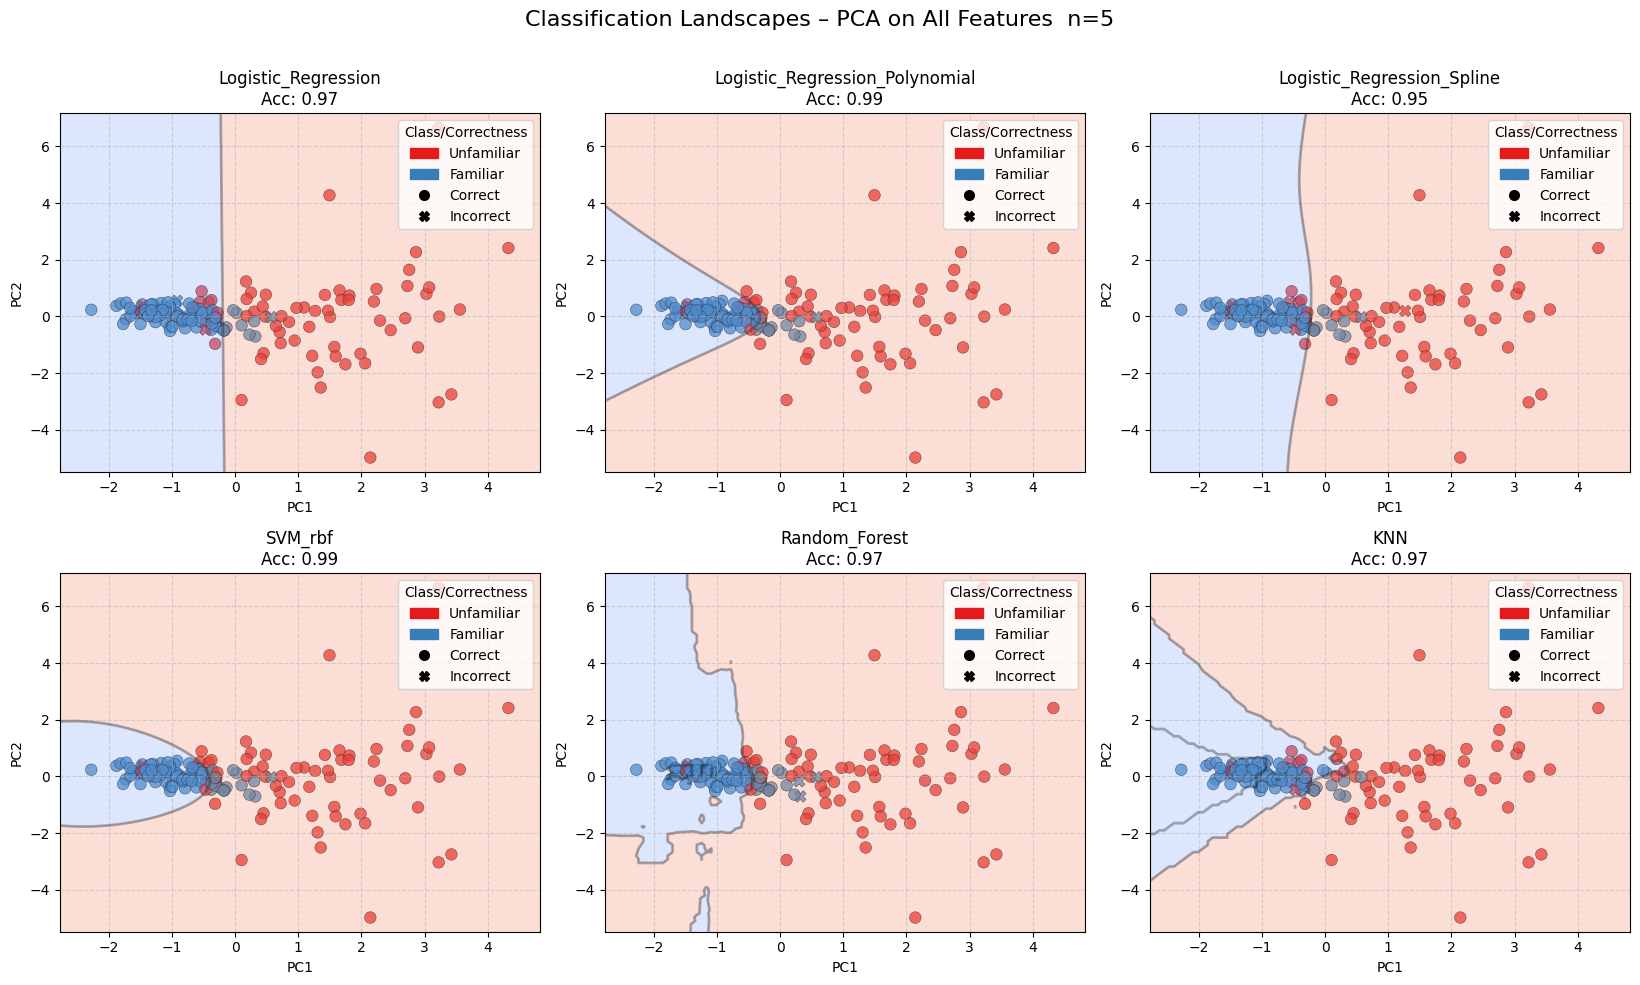

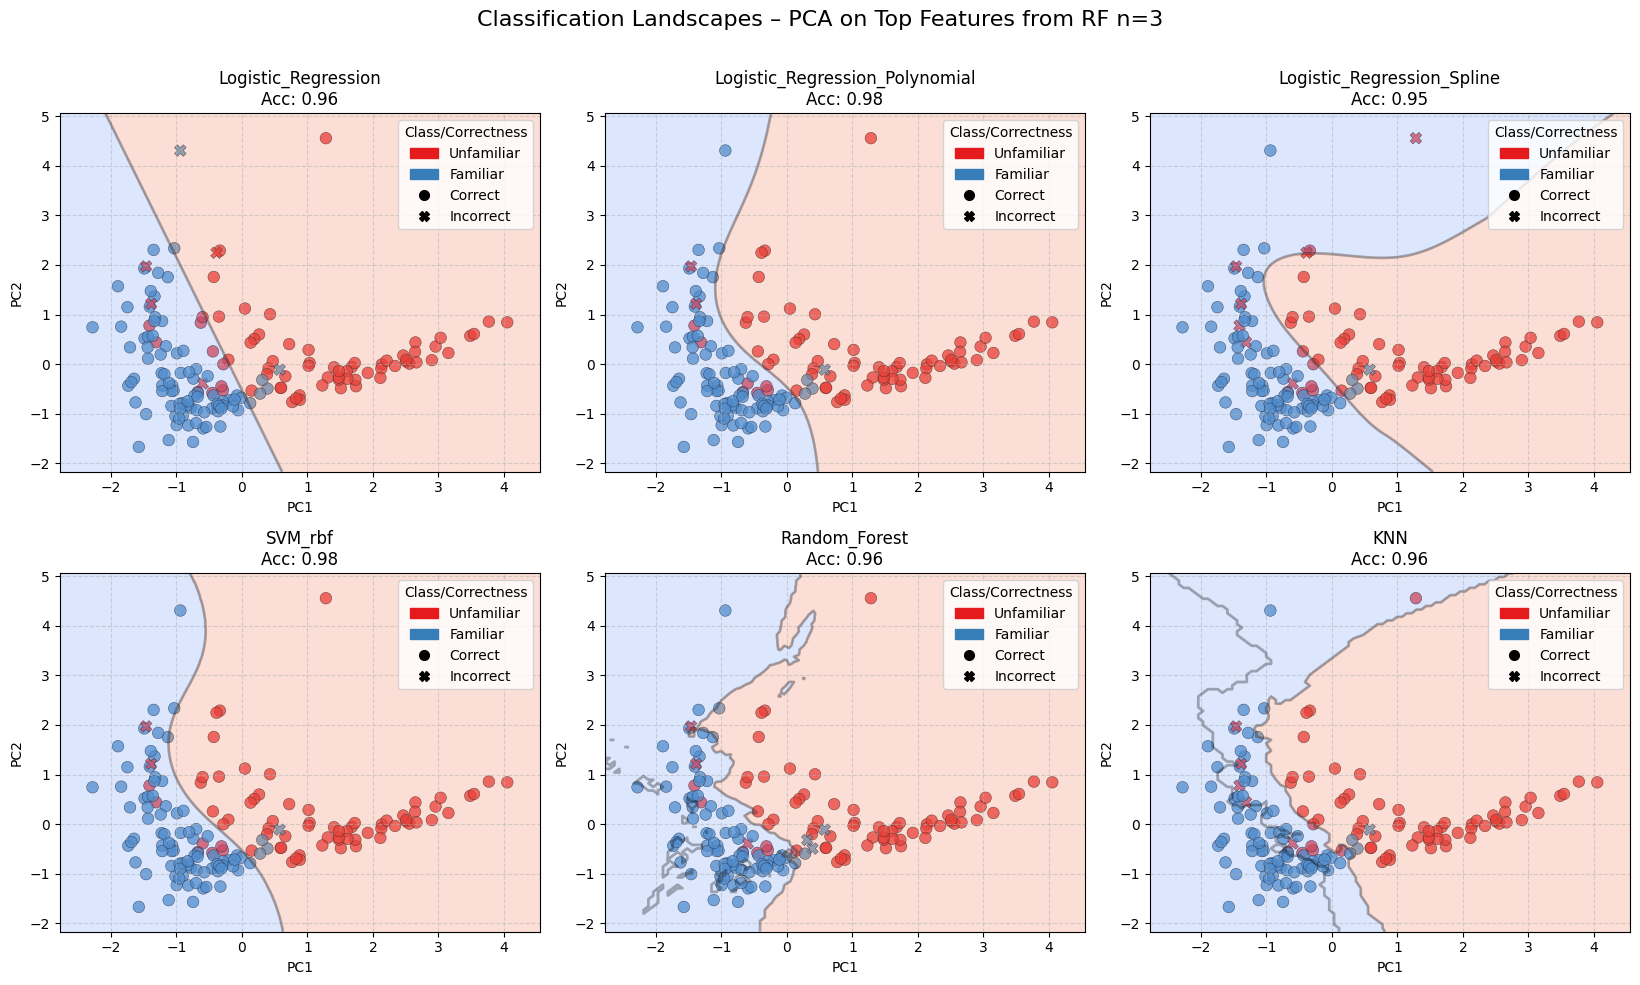

In [39]:
# plot the classification landscapes and decision boundaries for both sets of models

# plot for all features
plot_model_set_landscapes(
    X_test,
    models_predictions_df,
    models,
    results_df,
    selected_features,
    title_prefix=f"PCA on All Features  n={len(selected_features)}"
)
# plot for top n features from RF
plot_model_set_landscapes(
    X_test_rf,
    models_predictions_df_rf,
    models_rf,
    results_rf_df,
    selected_features_rf,
    title_prefix=f"PCA on Top Features from RF n={top_n_rf_features}"
)

### <span style="color:blue;">Interpretation</span> of the evaluation results
- all models and model types seem to perform very well on the classification task, with accuracies above **0.9** over the board.
- as exected, we are getting smooth decision boundaries for the **logistic regression** (Linear, Poly, Spline) and **SVM_rbf** models, while the non-parametric models (**KNN**, and **random forest**) are getting non-smoth and more scattered decision boundaries.   
   
more about model comparison in the next section.

## <span style="color:green;">6 - Model Comparison </span>

for model comparison, we will use the following 2 approachs:   
**in both approaches**, we will further compare between models trained on all features(A) and on the top features suggested by the random forest model(B).
- AIC for comparing logistic regression and its variations with different basis functions
  - this can be done since we can reliably compute the log-likelihood of the models and compare their free parameters  
  - AIC would make less sense for comparing models with completely different architectures like the other used models (SVM, RF, KNN)
- cross-validation on accuracy for comparing the other models amongst each other
  - although this method is not very informative nor intereptable, it is the most common approach for model comparison in ML especially amongst different classes of models.
  - we use K-fold(5) cross-validation
  - we use the accuracy score as the metric for comparison

In [52]:
# helper functionS for computing AIC

# get the number of free parameters in a model
def get_number_of_parameters(model):
    if isinstance(model, Pipeline):
        model = model[-1]

    if not hasattr(model, "coef_"):
        raise ValueError("Model does not have coefficients (coef_).")

    n_coeff = model.coef_.size  # total number of weights (flattened)
    n_intercepts = model.intercept_.size if hasattr(model, "intercept_") else 0

    return n_coeff + n_intercepts

# compute log-likelihood of the model
def compute_log_likelihood(model, X, y):
    if not hasattr(model, "predict_proba"):
        raise ValueError("Model must have `predict_proba` method to compute log-likelihood.")
    return -log_loss(y, model.predict_proba(X), normalize=False)

# compute AIC
def compute_aic(ll, k):
    aic = - 2 * ll + 2 * k 
    return round(aic, 3), k, round(ll, 3)

In [53]:
def aic_comparison(models_subset, x, y, verbose=False):
    aic_results = []
    for name, model in models_subset.items():
        try:
            if verbose:
                if isinstance(model, Pipeline):
                    # print all steps in the pipeline
                    print(f"Computing AIC for model:", model.named_steps) 
                else:
                    print(f"Computing AIC for model: {type(model).__name__}")
            
            # get k and ll
            k = get_number_of_parameters(model)
            ll = compute_log_likelihood(model, x, y)
            # compute AIC
            aic, k, ll = compute_aic(ll, k)
            # save results
            aic_results.append({
                "Model": name,
                "Free Params": k,
                "Log-Likelihood": round(ll, 2),
                "AIC": round(aic, 2)
            })
        except Exception as e:
            print(f"[Skipped AIC] {name}: {e}")
    return pd.DataFrame(aic_results).sort_values("AIC")

In [54]:
# separate models for each approach

# logistic regression models
logreg_models = {k: v for k, v in models.items() if "Logistic" in k}
logreg_models_rf = {k: v for k, v in models_rf.items() if "Logistic" in k}

# all other models
nonlogreg_models = {k: v for k, v in models.items() if "Logistic" not in k}
nonlogreg_models_rf = {k: v for k, v in models_rf.items() if "Logistic" not in k}

In [ ]:
# AIC
aic_df_all = aic_comparison(logreg_models, X_test, y_test)
aic_df_all["Feature Set"] = "All Features"

aic_df_rf = aic_comparison(logreg_models_rf, X_test_rf, y_test_rf)
aic_df_rf["Feature Set"] = "Top RF Features"

aic_combined = pd.concat([aic_df_all, aic_df_rf], ignore_index=True)
display("AIC Comparison Combined:", aic_combined)
# Cross-Validation
cv_all = cross_val_results_df.copy()
cv_all["Feature Set"] = "All Features"

cv_rf = cross_val_results_df_rf.copy()  
cv_rf["Feature Set"] = "Top RF Features"

cv_combined = pd.concat([cv_all, cv_rf]).reset_index(drop=False)
display("Cross-Validation Combined:", cv_combined)


'AIC Comparison Combined:'

,Model,Free Params,Log-Likelihood,AIC,Feature Set
0,Logistic_Regression,6,-18.53,49.06,All Features
1,Logistic_Regression_Spline,31,-29.02,120.05,All Features
2,Logistic_Regression_Polynomial,56,-12.25,136.51,All Features
3,Logistic_Regression,4,-19.04,46.07,Top RF Features
4,Logistic_Regression_Polynomial,20,-14.00,68.00,Top RF Features
5,Logistic_Regression_Spline,19,-29.22,96.44,Top RF Features


'Cross-Validation Combined:'

,Model,CV_accuracy_mean,CV_accuracy_Std,Feature Set
0,SVM_rbf,0.938,0.079,All Features
1,Logistic_Regression,0.926,0.084,All Features
2,Logistic_Regression_Polynomial,0.924,0.072,All Features
3,KNN,0.881,0.123,All Features
4,Logistic_Regression_Spline,0.870,0.126,All Features
5,Random_Forest,0.842,0.132,All Features
6,Logistic_Regression,0.929,0.087,Top RF Features
7,SVM_rbf,0.925,0.092,Top RF Features
8,Logistic_Regression_Polynomial,0.919,0.072,Top RF Features
9,KNN,0.886,0.113,Top RF Features


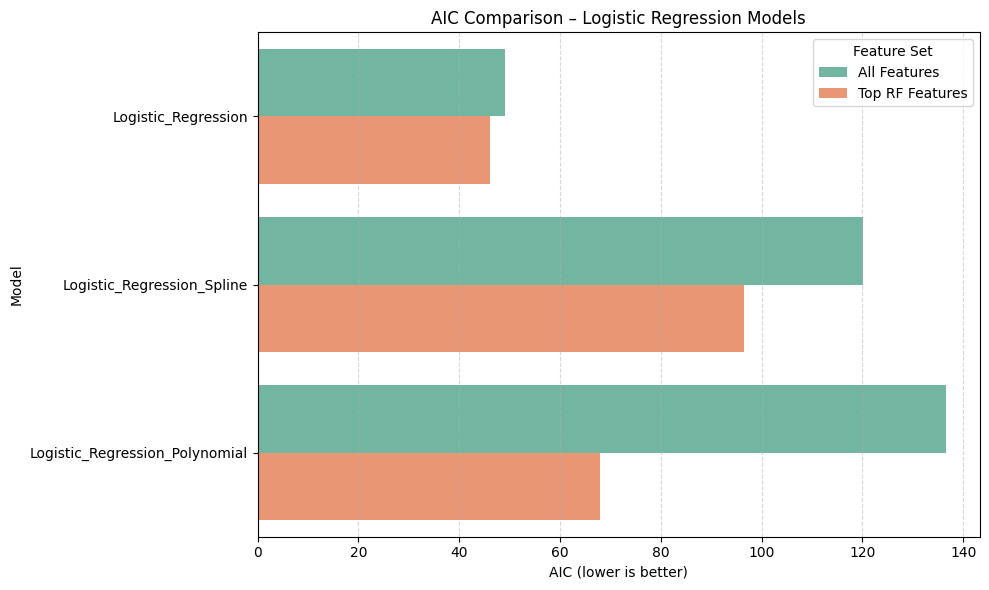

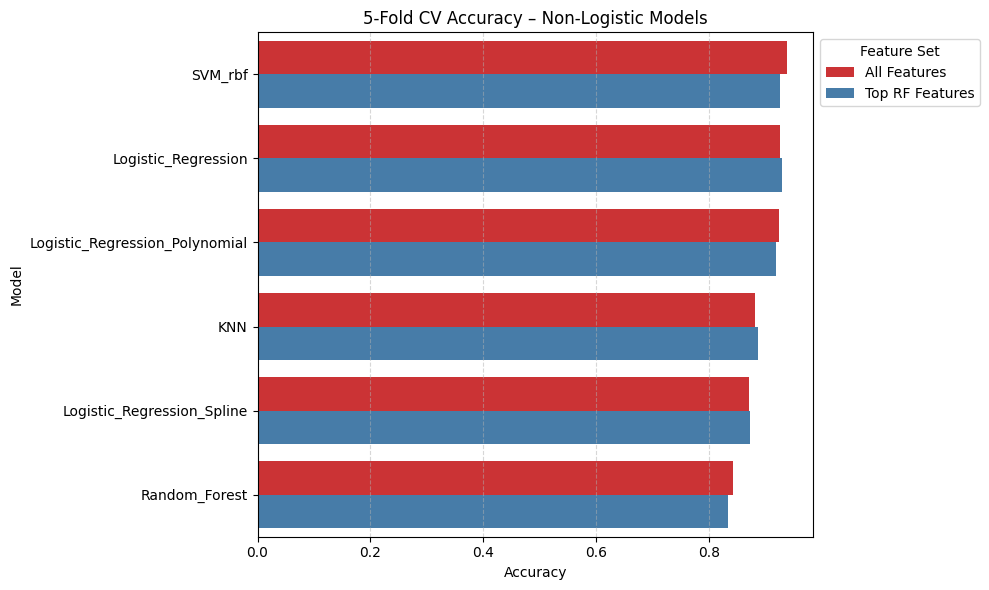

In [56]:
# AIC Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=aic_combined, x="AIC", y="Model", hue="Feature Set", palette="Set2")
plt.title("AIC Comparison – Logistic Regression Models")
plt.xlabel("AIC (lower is better)")
plt.ylabel("Model")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# CV Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=cv_combined, x="CV_accuracy_mean", y="Model", hue="Feature Set", palette="Set1")
plt.title("5-Fold CV Accuracy – Non-Logistic Models")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
# legends on the left
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Feature Set")
plt.tight_layout()
plt.show()


### <span style="color:blue;">Interpretation</span> of the model comparison results

We compared models using two approaches:
- **AIC** (Akaike Information Criterion)

  - Here, Only applied to **logistic regression models**, as it relies on computing log-likelihood and model complexity (free parameters).

  - Lowest AIC (best) was achieved by the basic (**lineear**) **Logistic Regression** model using **top RF-selected features**.

  - Adding complexity through **polynomial** or **spline** basis functions increased AIC, indicating overfitting without proportional gain in likelihood.

  - all regression models performed better on the reduced feature set(selected by Random forest)   
    - possibly fr_PC1, fr_PC2 and mean population firing rate are highly correlated in terms of their information content.    
    - suggesting that the original feature set may contain redundant or irrelevant features.
  
--> Overall, this suggests that, for our task, a simple linear logistic regression model may already be sufficient when using well-selected features.

- **k-Fold(5) Cross-Validation (Accuracy)**  (Used to compare all models)

  - The SVM (RBF kernel) consistently achieved the highest accuracy across both feature sets, although not by a big margin, demonstrating a slight edge for non-linear modeling capability.  
  
  - Surprisingly, Logistic Regression (even without non-linear expansions) performed almost as well, especially when using RF-selected features.

  - KNN and Random Forest performed fine but with higher variance, likely due to sensitivity to local feature structure or limited sample size.

--> Overall, feature selection (reduction) via Random Forest had neglegible effect on the models’ stability and accuracy.


- **Final Conclusion**

  - Logistic Regression with top features is the most efficient model by AIC.

  - SVM (RBF) is the most accurate model in terms of cross-validation (by small margin).

  - Feature selection using RF improves generalization and reduces model complexity without significant loss in accuracy.

--> Logistic Regression offers interpretability and simplicity, while SVM with non-linear kernel can still offer a slight edge on accuracy at the cost of complexity.    
--> Further Opitmization of the feature selection and encoding methods could improve the performance on the task.